In [895]:
import os
import csv
import numpy as np
import pandas as pd
from ase.io import read
import matplotlib.pyplot as plt

# Show float values with 2 decimal places when displaying DataFrames.
pd.options.display.float_format = '{:.2f}'.format

# Ensure wide DataFrames print all columns (no truncation).
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 20000)
pd.set_option('display.expand_frame_repr', True)

root = '/Users/jiuy97/Desktop/3_RuO2/6_ICOHP'
oxygen_potential = -4.658724749999999 # 300K
# oxygen_potential = -4.658724749999999+0.27-0.73 # 700K
figure_size = (4, 4)
dpi = 300

In [896]:
data = pd.DataFrame(index=['Ru', 'Hf', 'Ta', 'W', 'Re', 'Os'])

In [897]:
for dir in ['1_bulk_MO2', '2_bulk_MxOy', '3_bulk_M-RuO2']:
    oxide_type = dir.split('_')[2]
    for subdir in ['0_Ru', '1_Hf', '2_Ta', '3_W', '4_Re', '5_Os']:
        element = subdir.split('_')[1]
        path = os.path.join(root, dir, subdir)
        energy_file = os.path.join(path, 'final_with_calculator.json')
        if os.path.exists(energy_file):
            atoms = read(energy_file)
            n_atoms = len(atoms)
            n_oxygens = sum(atom.symbol == 'O' for atom in atoms)
            n_metals = n_atoms - n_oxygens
            oxidation_state = 2 * n_oxygens / n_metals
            energy = atoms.get_potential_energy() / n_metals
            data.loc[element, f'{oxide_type}_energy'] = energy
            if oxide_type == 'MxOy':
                data.loc[element, f'{oxide_type}_os'] = oxidation_state

data['MO2_fe'] = data['MO2_energy'] - (data['MxOy_energy'] + oxygen_potential * (2 - data['MxOy_os'] / 2))
data['M-RuO2_fe'] = data['M-RuO2_energy'] \
    - 1/8*(data['MxOy_energy'] + oxygen_potential * (2 - data['MxOy_os'] / 2)) \
    - 7/8*(data['MxOy_energy']['Ru'] + oxygen_potential * (2 - data['MxOy_os']['Ru'] / 2))
# data.drop(columns=['MO2_energy', 'MxOy_energy', 'M-RuO2_energy'], inplace=True)
data


,MO2_energy,MxOy_energy,MxOy_os,M-RuO2_energy,MO2_fe,M-RuO2_fe
Ru,-19.94,-19.94,4.00,-19.94,0.00,0.00
Hf,-30.48,-30.58,4.00,-21.16,0.10,0.11
Ta,-29.51,-34.15,5.00,-21.25,2.31,0.17
W,-28.49,-36.34,6.00,-21.09,3.19,0.31
Re,-25.90,-33.59,6.00,-20.76,3.04,0.30
Os,-23.78,-35.76,8.00,-20.44,2.67,0.31


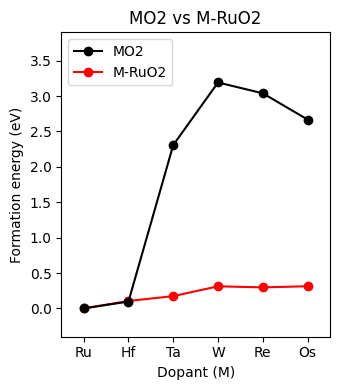

In [898]:
# Plot formation energies on a single figure (MO2 vs M-RuO2).
fig, ax = plt.subplots(1, 1, figsize=(3.5, 4))
colors = ['black', 'red']
zorders = [2, 1]

for i, col in enumerate(['MO2_fe', 'M-RuO2_fe']):
    oxide_type = col.split('_')[0]
    if col in data.columns:
        data[col].plot(kind='line', marker='o', ax=ax, label=oxide_type, color=colors[i % len(colors)], zorder=zorders[i % len(zorders)])

ax.set_title('MO2 vs M-RuO2')
ax.set_xlabel('Dopant (M)')
ax.set_ylabel('Formation energy (eV)')
ax.set_xticks(range(len(data.index)))
ax.set_xticklabels(data.index.tolist())
ax.legend(loc='best')
ax.set_xlim(-0.5, 5.5)
ax.set_ylim(-0.4, 3.9)

plt.tight_layout()
plt.savefig(f'{root}/fe.png', dpi=dpi)
plt.show()

In [899]:
for dir in ['1_bulk_MO2', '2_bulk_MxOy']:
    oxide_type = dir.split('_')[2]
    for subdir in ['0_Ru', '1_Hf', '2_Ta', '3_W', '4_Re', '5_Os']:
        element = subdir.split('_')[1]
        path = os.path.join(root, dir, subdir)
        chg_file = os.path.join(path, 'atoms_bader_charge.json')
        if os.path.exists(chg_file):
            atoms = read(chg_file)
            chgs = atoms.get_initial_charges()
            metal_chgs = [chg for atom, chg in zip(atoms, chgs) if atom.symbol != 'O']
            chg_metal = sum(metal_chgs) / len(metal_chgs)
            data.loc[element, f'{oxide_type}_chg'] = chg_metal
        mag_file = os.path.join(path, 'moments.json')
        if os.path.exists(mag_file):
            atoms = read(mag_file)
            mags = atoms.get_magnetic_moments()
            metal_mags = [abs(mag) for atom, mag in zip(atoms, mags) if atom.symbol != 'O']
            mag_metal = sum(metal_mags) / len(metal_mags)
            data.loc[element, f'{oxide_type}_mag'] = mag_metal
data

,MO2_energy,MxOy_energy,MxOy_os,M-RuO2_energy,MO2_fe,M-RuO2_fe,MO2_chg,MO2_mag,MxOy_chg,MxOy_mag
Ru,-19.94,-19.94,4.00,-19.94,0.00,0.00,1.74,1.35,1.74,1.35
Hf,-30.48,-30.58,4.00,-21.16,0.10,0.11,2.38,0.00,2.35,0.00
Ta,-29.51,-34.15,5.00,-21.25,2.31,0.17,2.15,0.00,2.64,0.00
W,-28.49,-36.34,6.00,-21.09,3.19,0.31,2.11,0.00,2.66,0.00
Re,-25.90,-33.59,6.00,-20.76,3.04,0.30,2.04,1.44,2.43,0.08
Os,-23.78,-35.76,8.00,-20.44,2.67,0.31,1.81,0.00,2.44,0.00


In [900]:
for dir in ['3_bulk_M-RuO2']:
    oxide_type = dir.split('_')[2]
    for subdir in ['0_Ru', '1_Hf', '2_Ta', '3_W', '4_Re', '5_Os']:
        element = subdir.split('_')[1]
        path = os.path.join(root, dir, subdir)
        atoms = read(os.path.join(path, 'final_with_calculator.json'))
        if element == 'Ru':
            M_index = [i for i, atom in enumerate(atoms) if atom.symbol == 'Ru']
            Ru_index = [i for i, atom in enumerate(atoms) if atom.symbol == 'Ru']
        else:
            M_index = [i for i, atom in enumerate(atoms) if atom.symbol != 'O' and atom.symbol != 'Ru']
            Ru_index = [i for i, atom in enumerate(atoms) if atom.symbol == 'Ru' and i != 4]
        
        chg_file = os.path.join(path, 'atoms_bader_charge.json')
        if os.path.exists(chg_file):
            atoms = read(chg_file)
            chgs = atoms.get_initial_charges()
            M_chg = sum(chgs[M_index])/len(M_index)
            Ru_chg = sum(chgs[Ru_index])/len(Ru_index)
            data.loc[element, f'{oxide_type}_chg_M'] = M_chg
            data.loc[element, f'{oxide_type}_chg_Ru'] = Ru_chg

        mag_file = os.path.join(path, 'moments.json')
        if os.path.exists(mag_file):
            atoms = read(mag_file)
            mags = atoms.get_magnetic_moments()
            M_mag = sum(abs(mags[i]) for i in M_index) / len(M_index)
            Ru_mag = sum(abs(mags[i]) for i in Ru_index) / len(Ru_index)
            data.loc[element, f'{oxide_type}_mag_M'] = M_mag
            data.loc[element, f'{oxide_type}_mag_Ru'] = Ru_mag
data

,MO2_energy,MxOy_energy,MxOy_os,M-RuO2_energy,MO2_fe,M-RuO2_fe,MO2_chg,MO2_mag,MxOy_chg,MxOy_mag,M-RuO2_chg_M,M-RuO2_chg_Ru,M-RuO2_mag_M,M-RuO2_mag_Ru
Ru,-19.94,-19.94,4.00,-19.94,0.00,0.00,1.74,1.35,1.74,1.35,1.74,1.74,1.35,1.35
Hf,-30.48,-30.58,4.00,-21.16,0.10,0.11,2.38,0.00,2.35,0.00,2.40,1.72,0.05,1.44
Ta,-29.51,-34.15,5.00,-21.25,2.31,0.17,2.15,0.00,2.64,0.00,2.64,1.68,0.05,1.30
W,-28.49,-36.34,6.00,-21.09,3.19,0.31,2.11,0.00,2.66,0.00,2.63,1.63,0.01,1.17
Re,-25.90,-33.59,6.00,-20.76,3.04,0.30,2.04,1.44,2.43,0.08,2.35,1.66,1.00,1.19
Os,-23.78,-35.76,8.00,-20.44,2.67,0.31,1.81,0.00,2.44,0.00,2.04,1.70,0.60,1.25


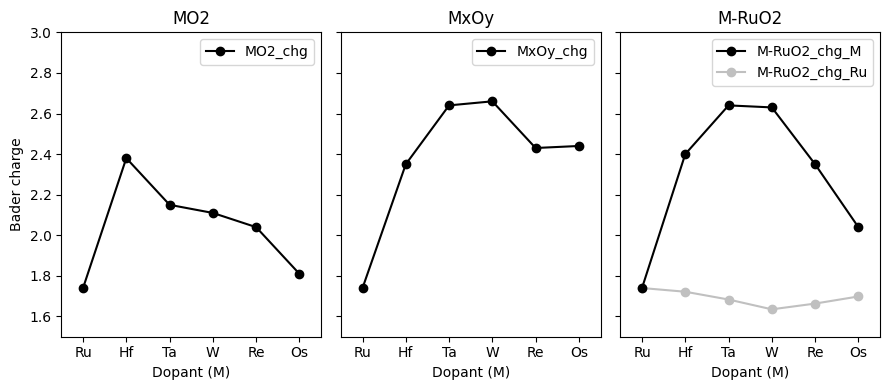

In [901]:
# Plot CHG-related columns for MO2, MxOy, and M-RuO2 side by side.
fig, axes = plt.subplots(1, 3, figsize=(9, 4), sharey=True)

groups = ['MO2', 'MxOy', 'M-RuO2']
colors = ['black', 'silver']
zorders = [2, 1]

for ax, group in zip(axes, groups):
    group_cols = [c for c in data.columns if group in c and 'chg' in c]
    
    for i, col in enumerate(group_cols):
        data[col].plot(
            kind='line',
            marker='o',
            ax=ax,
            color=colors[i % len(colors)],
            zorder=zorders[i % len(zorders)],
            label=col,
        )
    ax.set_title(group)
    ax.set_xlabel('Dopant (M)')

    ax.set_xlim(-0.5, 5.5)
    ax.set_xticks(range(len(data.index)))
    ax.set_xticklabels(data.index.tolist())
    ax.legend(loc='best')

axes[0].set_ylabel('Bader charge')
axes[0].set_ylim(1.5, 3.0)

plt.tight_layout()
plt.savefig(f'{root}/chg.png', dpi=dpi)
plt.show()

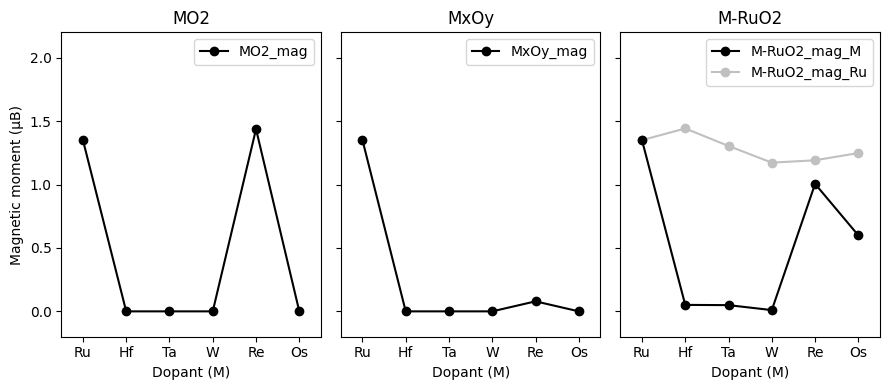

In [902]:
# Fixed: plot MAG-related columns with per-line zorder.
fig, axes = plt.subplots(1, 3, figsize=(9, 4), sharey=True)

groups = ['MO2', 'MxOy', 'M-RuO2']
colors = ['black', 'silver']
zorders = [2, 1]

for ax, group in zip(axes, groups):
    group_cols = [c for c in data.columns if group in c and 'mag' in c]

    for i, col in enumerate(group_cols):
        data[col].plot(
            kind='line',
            marker='o',
            ax=ax,
            color=colors[i % len(colors)],
            zorder=zorders[i % len(zorders)],
            label=col,
        )

    ax.set_title(group)
    ax.set_xlabel('Dopant (M)')
    
    ax.set_xlim(-0.5, 5.5)
    ax.set_xticks(range(len(data.index)))
    ax.set_xticklabels(data.index.tolist())
    ax.legend(loc='best')

axes[0].set_ylabel('Magnetic moment (μB)')
axes[0].set_ylim(-0.2, 2.2)

plt.tight_layout()
plt.savefig(f'{root}/mag.png', dpi=dpi)
plt.show()

In [903]:
def calculate_icohp_means_MO2(icohp_file):
    """
    Read one icohplist.txt file, extract the 7th column,
    and compute overall means across all complete chunks of 6 values.

    Chunk split rule:
    - First 4 chunks: split as 2 / 4
    - Remaining chunks: split as 4 / 2

    Then compute:
    - overall mean of all values from the 2-value groups
    - overall mean of all values from the 4-value groups
    """
    col7_values = []
    with open(icohp_file, 'r') as file:
        for line in file:
            columns = line.strip().split()
            if len(columns) >= 8:
                col7_values.append(columns[6])

    # Drop the first entry because it is the column header ('-ICOHP').
    numeric_values = [float(x) for x in col7_values[1:]]

    all_two_group = []
    all_four_group = []

    chunk_idx = 0
    for i in range(0, len(numeric_values), 6):
        chunk = numeric_values[i:i+6]
        if len(chunk) != 6:
            continue

        if chunk_idx < 4:
            all_two_group.extend(chunk[:2])
            all_four_group.extend(chunk[2:])
        else:
            all_four_group.extend(chunk[:4])
            all_two_group.extend(chunk[4:])

        chunk_idx += 1

    if not all_two_group or not all_four_group:
        return None

    overall_mean_axial = sum(all_two_group) / len(all_two_group)
    overall_mean_equatorial = sum(all_four_group) / len(all_four_group)
    overall_mean = sum(all_two_group + all_four_group) / len(all_two_group + all_four_group)

    return overall_mean_axial, overall_mean_equatorial, overall_mean

for dir in ['1_bulk_MO2']:
    oxide_type = dir.split('_')[2]
    for subdir in ['0_Ru', '1_Hf', '2_Ta', '3_W', '4_Re', '5_Os']:
        element = subdir.split('_')[1]
        icohp_file = os.path.join(root, dir, 'cohp', subdir, 'icohplist.txt')
        if os.path.exists(icohp_file):
            means = calculate_icohp_means_MO2(icohp_file)
            if means is not None:
                mean_axial, mean_equatorial, mean_overall = means
                data.loc[element, f'{oxide_type}_icohp_z'] = mean_axial
                data.loc[element, f'{oxide_type}_icohp_xy'] = mean_equatorial
                data.loc[element, f'{oxide_type}_icohp_all'] = mean_overall

data

,MO2_energy,MxOy_energy,MxOy_os,M-RuO2_energy,MO2_fe,M-RuO2_fe,MO2_chg,MO2_mag,MxOy_chg,MxOy_mag,M-RuO2_chg_M,M-RuO2_chg_Ru,M-RuO2_mag_M,M-RuO2_mag_Ru,MO2_icohp_z,MO2_icohp_xy,MO2_icohp_all
Ru,-19.94,-19.94,4.00,-19.94,0.00,0.00,1.74,1.35,1.74,1.35,1.74,1.74,1.35,1.35,2.01,1.60,1.74
Hf,-30.48,-30.58,4.00,-21.16,0.10,0.11,2.38,0.00,2.35,0.00,2.40,1.72,0.05,1.44,2.19,2.29,2.26
Ta,-29.51,-34.15,5.00,-21.25,2.31,0.17,2.15,0.00,2.64,0.00,2.64,1.68,0.05,1.30,2.46,2.12,2.23
W,-28.49,-36.34,6.00,-21.09,3.19,0.31,2.11,0.00,2.66,0.00,2.63,1.63,0.01,1.17,2.51,2.06,2.21
Re,-25.90,-33.59,6.00,-20.76,3.04,0.30,2.04,1.44,2.43,0.08,2.35,1.66,1.00,1.19,2.20,1.95,2.03
Os,-23.78,-35.76,8.00,-20.44,2.67,0.31,1.81,0.00,2.44,0.00,2.04,1.70,0.60,1.25,2.20,1.85,1.97


In [904]:
def calculate_icohp_mean_MxOy(icohp_file):
    """
    Read one icohplist.txt file, extract the 7th column,
    and compute one overall mean (no chunk split).
    """
    col7_values = []
    with open(icohp_file, 'r') as file:
        for line in file:
            columns = line.strip().split()
            if len(columns) >= 8:
                col7_values.append(columns[6])

    # Drop the first entry because it is the column header ('-ICOHP').
    numeric_values = [float(x) for x in col7_values[1:]]

    if not numeric_values:
        return None

    return sum(numeric_values) / len(numeric_values)

for dir in ['2_bulk_MxOy']:
    oxide_type = dir.split('_')[2]
    for subdir in ['0_Ru', '1_Hf', '2_Ta', '3_W', '4_Re', '5_Os']:
        element = subdir.split('_')[1]
        icohp_file = os.path.join(root, dir, 'cohp', subdir, 'icohplist.txt')
        if os.path.exists(icohp_file):
            mean_overall = calculate_icohp_mean_MxOy(icohp_file)
            if mean_overall is not None:
                # Keep existing column layout for downstream plotting.
                data.loc[element, f'{oxide_type}_icohp_all'] = mean_overall

data

,MO2_energy,MxOy_energy,MxOy_os,M-RuO2_energy,MO2_fe,M-RuO2_fe,MO2_chg,MO2_mag,MxOy_chg,MxOy_mag,M-RuO2_chg_M,M-RuO2_chg_Ru,M-RuO2_mag_M,M-RuO2_mag_Ru,MO2_icohp_z,MO2_icohp_xy,MO2_icohp_all,MxOy_icohp_all
Ru,-19.94,-19.94,4.00,-19.94,0.00,0.00,1.74,1.35,1.74,1.35,1.74,1.74,1.35,1.35,2.01,1.60,1.74,1.74
Hf,-30.48,-30.58,4.00,-21.16,0.10,0.11,2.38,0.00,2.35,0.00,2.40,1.72,0.05,1.44,2.19,2.29,2.26,1.95
Ta,-29.51,-34.15,5.00,-21.25,2.31,0.17,2.15,0.00,2.64,0.00,2.64,1.68,0.05,1.30,2.46,2.12,2.23,2.77
W,-28.49,-36.34,6.00,-21.09,3.19,0.31,2.11,0.00,2.66,0.00,2.63,1.63,0.01,1.17,2.51,2.06,2.21,3.28
Re,-25.90,-33.59,6.00,-20.76,3.04,0.30,2.04,1.44,2.43,0.08,2.35,1.66,1.00,1.19,2.20,1.95,2.03,3.13
Os,-23.78,-35.76,8.00,-20.44,2.67,0.31,1.81,0.00,2.44,0.00,2.04,1.70,0.60,1.25,2.20,1.85,1.97,5.78


In [905]:
def calculate_icohp_means_MRuO2(icohp_file):
    """
    Read one icohplist.txt file, extract the 7th column,
    and split by site type:
    - Ru site: first 7 chunks
    - M site : last 8th chunk

    For each 6-value chunk:
    - Ru chunks (0-3): 2 / 4 split
    - Ru chunks (4-6): 4 / 2 split
    - M chunk   (7)  : 4 / 2 split

    Returns:
    (Ru_mean_axial, Ru_mean_equatorial, Ru_mean,
     M_mean_axial, M_mean_equatorial, M_mean)
    """
    col7_values = []
    with open(icohp_file, 'r') as file:
        for line in file:
            columns = line.strip().split()
            if len(columns) >= 8:
                col7_values.append(columns[6])

    # Drop the first entry because it is the column header ('-ICOHP').
    numeric_values = [float(x) for x in col7_values[1:]]

    ru_two_group = []
    ru_four_group = []
    m_two_group = []
    m_four_group = []

    chunk_idx = 0
    for i in range(0, len(numeric_values), 6):
        chunk = numeric_values[i:i+6]
        if len(chunk) != 6:
            continue

        if chunk_idx < 3:
            # Ru chunks 0-3: 2 / 4
            ru_two_group.extend(chunk[:2])
            ru_four_group.extend(chunk[2:])
        elif 3 < chunk_idx < 7:
            # Ru chunks 4-6: 4 / 2
            ru_four_group.extend(chunk[:4])
            ru_two_group.extend(chunk[4:])
        elif chunk_idx == 7:
            # M chunk: 4 / 2
            m_four_group.extend(chunk[:4])
            m_two_group.extend(chunk[4:])

        chunk_idx += 1

    if not ru_two_group or not ru_four_group or not m_two_group or not m_four_group:
        return None

    Ru_mean_axial = sum(ru_two_group) / len(ru_two_group)
    Ru_mean_equatorial = sum(ru_four_group) / len(ru_four_group)
    Ru_mean = sum(ru_two_group + ru_four_group) / len(ru_two_group + ru_four_group)

    M_mean_axial = sum(m_two_group) / len(m_two_group)
    M_mean_equatorial = sum(m_four_group) / len(m_four_group)
    M_mean = sum(m_two_group + m_four_group) / len(m_two_group + m_four_group)

    return Ru_mean_axial, Ru_mean_equatorial, Ru_mean, M_mean_axial, M_mean_equatorial, M_mean

for dir in ['3_bulk_M-RuO2']:
    oxide_type = dir.split('_')[2]
    for subdir in ['0_Ru', '1_Hf', '2_Ta', '3_W', '4_Re', '5_Os']:
        element = subdir.split('_')[1]
        icohp_file = os.path.join(root, dir, 'cohp', subdir, 'icohplist.txt')
        if os.path.exists(icohp_file):
            means = calculate_icohp_means_MRuO2(icohp_file)
            if means is not None:
                (
                    Ru_mean_axial,
                    Ru_mean_equatorial,
                    Ru_mean,
                    M_mean_axial,
                    M_mean_equatorial,
                    M_mean,
                ) = means

                data.loc[element, f'{oxide_type}(Ru)_icohp_z'] = Ru_mean_axial
                data.loc[element, f'{oxide_type}(Ru)_icohp_xy'] = Ru_mean_equatorial
                data.loc[element, f'{oxide_type}(Ru)_icohp_all'] = Ru_mean

                data.loc[element, f'{oxide_type}(M)_icohp_z'] = M_mean_axial
                data.loc[element, f'{oxide_type}(M)_icohp_xy'] = M_mean_equatorial
                data.loc[element, f'{oxide_type}(M)_icohp_all'] = M_mean

data

,MO2_energy,MxOy_energy,MxOy_os,M-RuO2_energy,MO2_fe,M-RuO2_fe,MO2_chg,MO2_mag,MxOy_chg,MxOy_mag,M-RuO2_chg_M,M-RuO2_chg_Ru,M-RuO2_mag_M,M-RuO2_mag_Ru,MO2_icohp_z,MO2_icohp_xy,MO2_icohp_all,MxOy_icohp_all,M-RuO2(Ru)_icohp_z,M-RuO2(Ru)_icohp_xy,M-RuO2(Ru)_icohp_all,M-RuO2(M)_icohp_z,M-RuO2(M)_icohp_xy,M-RuO2(M)_icohp_all
Ru,-19.94,-19.94,4.00,-19.94,0.00,0.00,1.74,1.35,1.74,1.35,1.74,1.74,1.35,1.35,2.01,1.60,1.74,1.74,2.01,1.60,1.74,2.01,1.60,1.74
Hf,-30.48,-30.58,4.00,-21.16,0.10,0.11,2.38,0.00,2.35,0.00,2.40,1.72,0.05,1.44,2.19,2.29,2.26,1.95,1.93,1.57,1.69,2.42,2.27,2.32
Ta,-29.51,-34.15,5.00,-21.25,2.31,0.17,2.15,0.00,2.64,0.00,2.64,1.68,0.05,1.30,2.46,2.12,2.23,2.77,1.91,1.54,1.66,2.89,2.76,2.80
W,-28.49,-36.34,6.00,-21.09,3.19,0.31,2.11,0.00,2.66,0.00,2.63,1.63,0.01,1.17,2.51,2.06,2.21,3.28,1.85,1.52,1.63,3.06,3.13,3.10
Re,-25.90,-33.59,6.00,-20.76,3.04,0.30,2.04,1.44,2.43,0.08,2.35,1.66,1.00,1.19,2.20,1.95,2.03,3.13,1.94,1.55,1.68,2.93,2.57,2.69
Os,-23.78,-35.76,8.00,-20.44,2.67,0.31,1.81,0.00,2.44,0.00,2.04,1.70,0.60,1.25,2.20,1.85,1.97,5.78,1.97,1.57,1.70,2.68,2.14,2.32


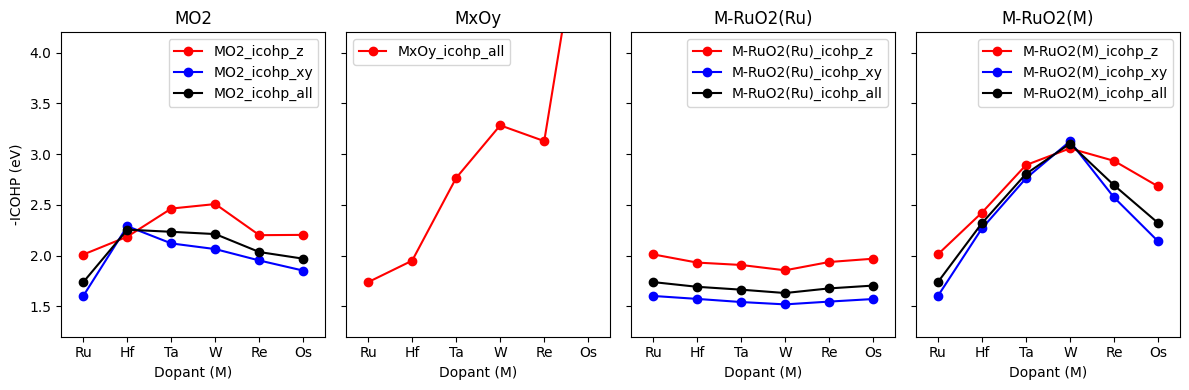

In [906]:
# Fixed: plot MAG-related columns with per-line zorder.
fig, axes = plt.subplots(1, 4, figsize=(12, 4), sharey=True)

groups = ['MO2', 'MxOy', 'M-RuO2(Ru)', 'M-RuO2(M)']
colors = ['red', 'blue', 'black']
zorders = [1, 2, 3]

for ax, group in zip(axes, groups):
    group_cols = [c for c in data.columns if group in c and 'icohp' in c]

    for i, col in enumerate(group_cols):
        data[col].plot(
            kind='line',
            marker='o',
            ax=ax,
            color=colors[i % len(colors)],
            zorder=zorders[i % len(zorders)],
            label=col,
        )

    ax.set_title(group)
    ax.set_xlabel('Dopant (M)')
    
    ax.set_xlim(-0.5, 5.5)
    ax.set_xticks(range(len(data.index)))
    ax.set_xticklabels(data.index.tolist())
    ax.legend(loc='best')

axes[0].set_ylabel('-ICOHP (eV)')
axes[0].set_ylim(1.2, 4.2)

plt.tight_layout()
plt.savefig(f'{root}/icohp.png', dpi=dpi)
plt.show()

In [907]:
RuO2_path = os.path.join(root, '4_slab_M-RuO2', '1_cus_V_V', '0_Ru')
RuO2_atoms = read(os.path.join(RuO2_path, 'final_with_calculator.json'))
RuO2_energy = RuO2_atoms.get_potential_energy()

for dir in ['1_cus_V_V', '2_brg_V_V']:
    ads_site = dir.split('_')[1]
    coverage = dir.split('_')[2]

    for subdir in ['0_Ru', '1_Hf', '2_Ta', '3_W', '4_Re', '5_Os']:
        element = subdir.split('_')[1]
        path = os.path.join(root, '4_slab_M-RuO2', dir, subdir)
        energy_file = os.path.join(path, 'final_with_calculator.json')
        if os.path.exists(energy_file):
            atoms = read(energy_file)
            energy = atoms.get_potential_energy()
            
            doping_energy_MxOy = (energy - data['MxOy_energy'][element] + oxygen_potential * data['MxOy_os'][element] / 2) \
                - (RuO2_energy - data['MxOy_energy']['Ru'] + oxygen_potential * data['MxOy_os']['Ru'] / 2)
            data.loc[element, f'{ads_site}_{coverage}_de_MxOy'] = doping_energy_MxOy

            doping_energy_MO2 = (energy - data['MO2_energy'][element]) - (RuO2_energy - data['MO2_energy']['Ru'])
            data.loc[element, f'{ads_site}_{coverage}_de_MO2'] = doping_energy_MO2
            
data


,MO2_energy,MxOy_energy,MxOy_os,M-RuO2_energy,MO2_fe,M-RuO2_fe,MO2_chg,MO2_mag,MxOy_chg,MxOy_mag,M-RuO2_chg_M,M-RuO2_chg_Ru,M-RuO2_mag_M,M-RuO2_mag_Ru,MO2_icohp_z,MO2_icohp_xy,MO2_icohp_all,MxOy_icohp_all,M-RuO2(Ru)_icohp_z,M-RuO2(Ru)_icohp_xy,M-RuO2(Ru)_icohp_all,M-RuO2(M)_icohp_z,M-RuO2(M)_icohp_xy,M-RuO2(M)_icohp_all,cus_V_de_MxOy,cus_V_de_MO2,brg_V_de_MxOy,brg_V_de_MO2
Ru,-19.94,-19.94,4.00,-19.94,0.00,0.00,1.74,1.35,1.74,1.35,1.74,1.74,1.35,1.35,2.01,1.60,1.74,1.74,2.01,1.60,1.74,2.01,1.60,1.74,0.00,0.00,0.00,0.00
Hf,-30.48,-30.58,4.00,-21.16,0.10,0.11,2.38,0.00,2.35,0.00,2.40,1.72,0.05,1.44,2.19,2.29,2.26,1.95,1.93,1.57,1.69,2.42,2.27,2.32,0.50,0.40,0.40,0.30
Ta,-29.51,-34.15,5.00,-21.25,2.31,0.17,2.15,0.00,2.64,0.00,2.64,1.68,0.05,1.30,2.46,2.12,2.23,2.77,1.91,1.54,1.66,2.89,2.76,2.80,1.22,-1.09,0.51,-1.79
W,-28.49,-36.34,6.00,-21.09,3.19,0.31,2.11,0.00,2.66,0.00,2.63,1.63,0.01,1.17,2.51,2.06,2.21,3.28,1.85,1.52,1.63,3.06,3.13,3.10,2.57,-0.62,1.16,-2.03
Re,-25.90,-33.59,6.00,-20.76,3.04,0.30,2.04,1.44,2.43,0.08,2.35,1.66,1.00,1.19,2.20,1.95,2.03,3.13,1.94,1.55,1.68,2.93,2.57,2.69,2.56,-0.48,1.40,-1.64
Os,-23.78,-35.76,8.00,-20.44,2.67,0.31,1.81,0.00,2.44,0.00,2.04,1.70,0.60,1.25,2.20,1.85,1.97,5.78,1.97,1.57,1.70,2.68,2.14,2.32,2.86,0.19,2.13,-0.54


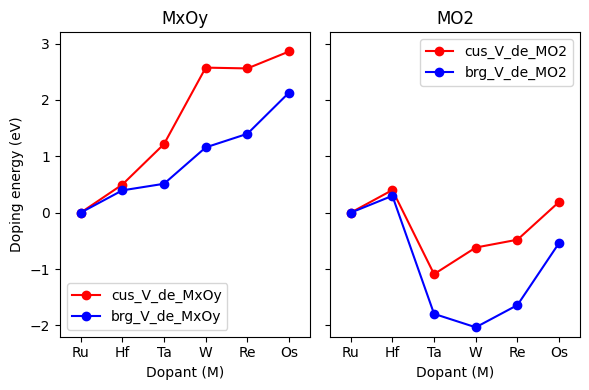

In [ ]:
# Fixed: plot MAG-related columns with per-line zorder.
fig, axes = plt.subplots(1, 2, figsize=(6, 4), sharey=True)

groups = ['MxOy', 'MO2']
colors = ['red', 'blue', 'black']
zorders = [1, 2, 3]

for ax, group in zip(axes, groups):
    group_cols = [c for c in data.columns if group in c and 'V_de' in c]

    for i, col in enumerate(group_cols):
        data[col].plot(
            kind='line',
            marker='o',
            ax=ax,
            color=colors[i % len(colors)],
            zorder=zorders[i % len(zorders)],
            label=col,
        )

    ax.set_title(group)
    ax.set_xlabel('Dopant (M)')
    
    ax.set_xlim(-0.5, 5.5)
    ax.set_xticks(range(len(data.index)))
    ax.set_xticklabels(data.index.tolist())
    ax.legend(loc='best')

axes[0].set_ylabel('Doping energy (eV)')
axes[0].set_ylim(-2.4, 3.2)

plt.tight_layout()
plt.savefig(f'{root}/de_v.png', dpi=dpi)
plt.show()

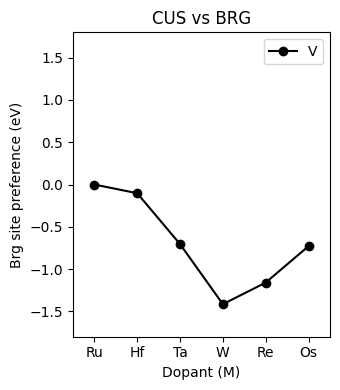

In [909]:
data['V_Δde'] = data['brg_V_de_MxOy'] - data['cus_V_de_MxOy']

# Plot formation energies on a single figure (MO2 vs M-RuO2).
fig, ax = plt.subplots(1, 1, figsize=(3.5, 4))
colors = ['black', 'red']
zorders = [2, 1]

for i, col in enumerate(['V_Δde']):
    oxide_type = col.split('_')[0]
    if col in data.columns:
        data[col].plot(kind='line', marker='o', ax=ax, label=oxide_type, color=colors[i % len(colors)], zorder=zorders[i % len(zorders)])

ax.set_title('CUS vs BRG')
ax.set_xlabel('Dopant (M)')
ax.set_ylabel('Brg site preference (eV)')
ax.set_xticks(range(len(data.index)))
ax.set_xticklabels(data.index.tolist())
ax.legend(loc='best')
ax.set_xlim(-0.5, 5.5)
ax.set_ylim(-1.8, 1.8)

plt.tight_layout()
plt.savefig(f'{root}/delta_de_v.png', dpi=dpi)
plt.show()

In [910]:
RuO2_path = os.path.join(root, '4_slab_M-RuO2', '3_cus_O_O', '0_Ru')
RuO2_atoms = read(os.path.join(RuO2_path, 'final_with_calculator.json'))
RuO2_energy = RuO2_atoms.get_potential_energy()

for dir in ['3_cus_O_O', '4_brg_O_O']:
    ads_site = dir.split('_')[1]
    coverage = dir.split('_')[2]

    for subdir in ['0_Ru', '1_Hf', '2_Ta', '3_W', '4_Re', '5_Os']:
        element = subdir.split('_')[1]
        path = os.path.join(root, '4_slab_M-RuO2', dir, subdir)
        energy_file = os.path.join(path, 'final_with_calculator.json')
        if os.path.exists(energy_file):
            atoms = read(energy_file)
            energy = atoms.get_potential_energy()
            
            doping_energy_MxOy = (energy - data['MxOy_energy'][element] + oxygen_potential * data['MxOy_os'][element] / 2) \
                - (RuO2_energy - data['MxOy_energy']['Ru'] + oxygen_potential * data['MxOy_os']['Ru'] / 2)
            data.loc[element, f'{ads_site}_{coverage}_de_MxOy'] = doping_energy_MxOy

            doping_energy_MO2 = (energy - data['MO2_energy'][element]) - (RuO2_energy - data['MO2_energy']['Ru'])
            data.loc[element, f'{ads_site}_{coverage}_de_MO2'] = doping_energy_MO2
            
data


,MO2_energy,MxOy_energy,MxOy_os,M-RuO2_energy,MO2_fe,M-RuO2_fe,MO2_chg,MO2_mag,MxOy_chg,MxOy_mag,M-RuO2_chg_M,M-RuO2_chg_Ru,M-RuO2_mag_M,M-RuO2_mag_Ru,MO2_icohp_z,MO2_icohp_xy,MO2_icohp_all,MxOy_icohp_all,M-RuO2(Ru)_icohp_z,M-RuO2(Ru)_icohp_xy,M-RuO2(Ru)_icohp_all,M-RuO2(M)_icohp_z,M-RuO2(M)_icohp_xy,M-RuO2(M)_icohp_all,cus_V_de_MxOy,cus_V_de_MO2,brg_V_de_MxOy,brg_V_de_MO2,V_Δde,cus_O_de_MxOy,cus_O_de_MO2,brg_O_de_MxOy,brg_O_de_MO2
Ru,-19.94,-19.94,4.00,-19.94,0.00,0.00,1.74,1.35,1.74,1.35,1.74,1.74,1.35,1.35,2.01,1.60,1.74,1.74,2.01,1.60,1.74,2.01,1.60,1.74,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN
Hf,-30.48,-30.58,4.00,-21.16,0.10,0.11,2.38,0.00,2.35,0.00,2.40,1.72,0.05,1.44,2.19,2.29,2.26,1.95,1.93,1.57,1.69,2.42,2.27,2.32,0.50,0.40,0.40,0.30,-0.10,NaN,NaN,0.65,0.55
Ta,-29.51,-34.15,5.00,-21.25,2.31,0.17,2.15,0.00,2.64,0.00,2.64,1.68,0.05,1.30,2.46,2.12,2.23,2.77,1.91,1.54,1.66,2.89,2.76,2.80,1.22,-1.09,0.51,-1.79,-0.70,1.09,-1.22,0.58,-1.73
W,-28.49,-36.34,6.00,-21.09,3.19,0.31,2.11,0.00,2.66,0.00,2.63,1.63,0.01,1.17,2.51,2.06,2.21,3.28,1.85,1.52,1.63,3.06,3.13,3.10,2.57,-0.62,1.16,-2.03,-1.42,1.49,-1.70,1.08,-2.11
Re,-25.90,-33.59,6.00,-20.76,3.04,0.30,2.04,1.44,2.43,0.08,2.35,1.66,1.00,1.19,2.20,1.95,2.03,3.13,1.94,1.55,1.68,2.93,2.57,2.69,2.56,-0.48,1.40,-1.64,-1.16,1.20,-1.84,1.04,-1.99
Os,-23.78,-35.76,8.00,-20.44,2.67,0.31,1.81,0.00,2.44,0.00,2.04,1.70,0.60,1.25,2.20,1.85,1.97,5.78,1.97,1.57,1.70,2.68,2.14,2.32,2.86,0.19,2.13,-0.54,-0.73,1.63,-1.03,2.11,-0.55


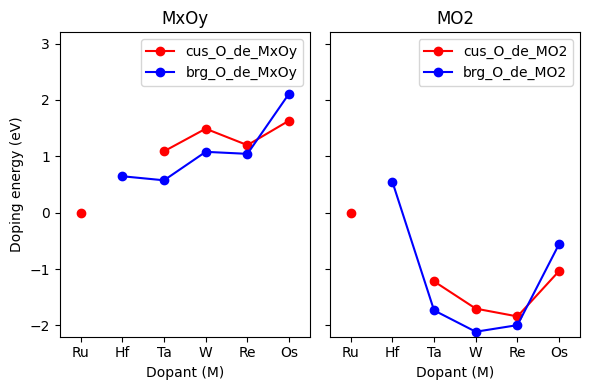

In [ ]:
# Fixed: plot MAG-related columns with per-line zorder.
fig, axes = plt.subplots(1, 2, figsize=(6, 4), sharey=True)

groups = ['MxOy', 'MO2']
colors = ['red', 'blue', 'black']
zorders = [1, 2, 3]

for ax, group in zip(axes, groups):
    group_cols = [c for c in data.columns if group in c and 'O_de' in c]

    for i, col in enumerate(group_cols):
        data[col].plot(
            kind='line',
            marker='o',
            ax=ax,
            color=colors[i % len(colors)],
            zorder=zorders[i % len(zorders)],
            label=col,
        )

    ax.set_title(group)
    ax.set_xlabel('Dopant (M)')
    
    ax.set_xlim(-0.5, 5.5)
    ax.set_xticks(range(len(data.index)))
    ax.set_xticklabels(data.index.tolist())
    ax.legend(loc='best')

axes[0].set_ylabel('Doping energy (eV)')
axes[0].set_ylim(-2.4, 3.2)

plt.tight_layout()
plt.savefig(f'{root}/de_o.png', dpi=dpi)
plt.show()